In [14]:
# =========================================================
# CONFIGURATION & HYPER-PARAMETERS FOR SHAP/LIME EXPLAINABILITY
# =========================================================
import os, sys
import torch
import numpy as np
import pandas as pd

# Add repository root to python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))

# Configurable experiment settings
DATASET_NAME = "UIT-VSFC"
SEED = 123
RDF_PATH = "ontology/ekman_appraisal_ontology.rdf"
CHECKPOINT_PATH = "results/phobert_gate_m3_vsfc.pth"
EXPLAIN_SENTENCE = "giảng viên nhiệt tình trong công tác giảng dạy ."

# Set random seed for reproducibility
def seed_everything(seed=42):
    import random
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Configured environment for {DATASET_NAME} (Seed: {SEED}) on device: {device}")


/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/phobert_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsfc_ekman_raw_gate_m3.pth
/kaggle/input/models/thnhcng123/kg-phobert/other/default/1/vsmec_gate_m3.pth
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_5.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_7.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_4.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_9.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_6.rdf
/kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_8.rdf
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/README.txt
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/test/topics.txt
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/test/sentiments.txt
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/test/sents.txt
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/train/topics.txt
/kaggle/input/datasets/minkduck/uit-vsfc/UIT-VSFC/train/sentiments.txt
/kaggle/input/da

In [15]:
import random
import numpy as np
import torch
import os

def seed_everything(seed=2024):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Thiết lập seed cố định
seed_everything(2025)
print("✅ Đã thiết lập Random Seed: (Kết quả sẽ cố định mỗi lần chạy)")

✅ Đã thiết lập Random Seed: (Kết quả sẽ cố định mỗi lần chạy)


In [16]:
# =========================================================
# CELL 2: ONTOLOGY ENGINE V12.3 (VSFC SPECIALIZED)
# Target: TỐI ƯU HÓA CHO 3 NHÃN (POS/NEG/NEU)
# Change Log:
#   - Polarity Injection: Dồn điểm Emotion vào Polarity.
#   - Aggressive Inference: Tự động map mạnh hơn.
# =========================================================
# # !pip install -q pyvi rdflib unidecode

import os, re
import numpy as np
import rdflib
from rdflib import Graph, Namespace
from rdflib.namespace import RDF
from pyvi import ViTokenizer
from unidecode import unidecode

class VSFCOntologyEngine:
    def __init__(self, rdfpath, defaultconf=0.9, negation_attenuation=0.4, alpha_similarity=0.2, verbose=True):
        self.EKMAN = Namespace("http://example.org/ekman-ontology#")
        # Tăng defaultconf để tin tưởng KG hơn cho bài toán Sentiment
        self.defaultconf = float(defaultconf)
        self.negation_attenuation = float(negation_attenuation) 
        self.alpha_similarity = float(alpha_similarity)
        self.verbose = bool(verbose)

        # 1. CONFIGS
        self.ALLEMOTIONS = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
        # VSFC: Quan trọng nhất là POLARITY
        self.POLARITY_CLASSES = ["PositivePolarity", "NegativePolarity", "NeutralPolarity"]
        self.INTENSITY_CLASSES = ["HighIntensity", "MediumIntensity", "LowIntensity"]
        self.ALLAPPRAISALS = [
            "GoalObstructionAppraisal", "PleasantnessAppraisal", "UnpleasantnessAppraisal", 
            "DangerousnessAppraisal", "LossAppraisal", "SuddennessAppraisal", 
            "LowPredictabilityAppraisal", "UnpredictabilityAppraisal", "UnfairnessAppraisal"
        ]

        # Mapping Emotion -> Polarity (Dùng để tiêm điểm - Injection)
        self.POS_EMOTIONS = {"Happiness", "Enjoyment", "Surprise"} # Surprise trong VSFC thường là tích cực hoặc neutral
        self.NEG_EMOTIONS = {"Anger", "Disgust", "Fear", "Sadness"}
        
        self.EMOTIONMAPPING = {
            "Enjoyment": "Happiness", "Happiness": "Happiness", "Anger": "Anger", "Disgust": "Disgust", 
            "Fear": "Fear", "Sadness": "Sadness", "Surprise": "Surprise", 
            "NeutralEmotion": "Neutral", "Neutral": "Neutral", "Other": "Neutral", "NegationCue": "NegationCue"
        }
        
        # Dictionary cho Deep Inference
        self.IMPLIED_POLARITY = {
            "Anger": "NegativePolarity", "Disgust": "NegativePolarity",
            "Fear": "NegativePolarity", "Sadness": "NegativePolarity",
            "Happiness": "PositivePolarity", "Enjoyment": "PositivePolarity",
            "Surprise": "PositivePolarity", 
            "UnpleasantnessAppraisal": "NegativePolarity",
            "GoalObstructionAppraisal": "NegativePolarity", 
            "LossAppraisal": "NegativePolarity",
            "UnfairnessAppraisal": "NegativePolarity",
            "DangerousnessAppraisal": "NegativePolarity",
            "PleasantnessAppraisal": "PositivePolarity"
        }
        
        self.AMBIGUOUS_TERMS = {
            "hay", "chả", "cơ", "ngờ", "ý", "quá", "lại", 
            "tôi", "tao", "tớ", "mình", "bạn", "nó", "hắn", "anh", "chị", "em",
            "là", "thì", "mà", "bị", "được", "cái", "con", "người"
        }
        self.VALID_DOMAINS = {"GeneralDomain", "SocialDomain", "EducationDomain"}
        
        # LOAD KG
        if self.verbose: print(f"📥 Loading KG for VSFC (Specialized v12.3): {rdfpath}")
        self.g = Graph()
        if os.path.exists(rdfpath):
            self.g.parse(rdfpath)
            if self.verbose: print(f"   ✅ Loaded {len(self.g)} triples.")
        else:
            print(f"   ⚠️ ERROR: File not found {rdfpath}")

        self.sim_matrix = self._build_similarity_matrix()
        self.lexiconmap = self._build_strict_lexicon()
        
        self.mwe_max_len = 1
        for k in self.lexiconmap.keys(): self.mwe_max_len = max(self.mwe_max_len, len(k.split()))

    def _norm(self, s): return re.sub(r"\s+", " ", str(s).lower().strip().replace("_", " ")).strip() if s else ""
    def _local(self, uri): return str(uri).split("#")[-1] if "#" in str(uri) else str(uri).split("/")[-1]

    def _build_similarity_matrix(self):
        n = len(self.ALLEMOTIONS)
        mat = np.zeros((n, n), dtype=np.float32); np.fill_diagonal(mat, 1.0)
        try:
            q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?score ?e1 ?e2 WHERE { ?edge a ekman:EmotionSimilarityEdge ; ekman:similarityScore ?score ; ekman:linksEmotion ?e1 ; ekman:linksEmotion ?e2 . }"""
            for row in self.g.query(q):
                e1, e2 = self.EMOTIONMAPPING.get(self._local(row.e1)), self.EMOTIONMAPPING.get(self._local(row.e2))
                if e1 in self.ALLEMOTIONS and e2 in self.ALLEMOTIONS:
                    i, j = self.ALLEMOTIONS.index(e1), self.ALLEMOTIONS.index(e2)
                    mat[i, j] = mat[j, i] = max(mat[i, j], float(row.score))
        except: pass
        s = mat.sum(axis=1, keepdims=True); s[s==0] = 1.0
        return mat / s

    def _build_strict_lexicon(self):
        EK, lookup = self.EKMAN, {}
        mix_cache, sim_cache = {}, {}
        
        # Cache Mixtures
        for r in self.g.query("PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?m ?e ?w WHERE { ?m a ekman:EmotionMixture ; ekman:hasComponent ?c . ?c ekman:componentEmotion ?e ; ekman:componentWeight ?w . }"):
            m, e, w = r.m, self.EMOTIONMAPPING.get(self._local(r.e)), float(r.w)
            if e in self.ALLEMOTIONS: mix_cache.setdefault(m, {})[e] = mix_cache.setdefault(m, {}).get(e, 0.0) + w
        
        # Cache Categories
        for s, _, o in self.g.triples((None, EK.hasEmotionCategory, None)):
            e = self.EMOTIONMAPPING.get(self._local(o))
            if e in self.ALLEMOTIONS: sim_cache[s] = [e]
            
        for s in self.g.subjects(RDF.type, None):
            if s in mix_cache or s in sim_cache: continue
            ts = list(self.g.objects(s, RDF.type))
            if EK.NegationCue in ts: sim_cache[s] = ["NegationCue"]
            else:
                for t in ts:
                    m = self.EMOTIONMAPPING.get(self._local(t))
                    if m in self.ALLEMOTIONS: sim_cache[s] = [m]; break
        
        # Build Lexicon with Deep Inference
        q = """PREFIX ekman: <http://example.org/ekman-ontology#> SELECT ?word ?stim ?ev ?base ?type ?dom WHERE { ?evoc a ekman:Evocation ; ekman:fromLexiconEntry ?lex ; ekman:toStimulus ?stim . ?lex ekman:hasContent ?word . OPTIONAL { ?evoc ekman:confidenceScore ?ev } OPTIONAL { ?evoc ekman:evidenceType ?type } OPTIONAL { ?lex ekman:baseIntensityScore ?base } OPTIONAL { ?lex ekman:belongsToDomain ?dom } }"""
        for r in self.g.query(q):
            if r.dom and self._local(r.dom) not in self.VALID_DOMAINS: continue 
            w = self._norm(r.word)
            if len(w) < 2 or w in self.AMBIGUOUS_TERMS: continue
            
            emos = {}
            if r.stim in mix_cache:
                raw = mix_cache[r.stim]; tot = sum(raw.values())
                if tot > 0: emos = {k: v/tot for k, v in raw.items()}
            elif r.stim in sim_cache:
                lst = sim_cache[r.stim]
                emos = {k: 1.0 for k in lst}
            if not emos: continue

            apps, ints, pols = self._infer_attributes(r.stim, emos.keys())
            
            entry_score = float(r.ev or self.defaultconf) * float(r.base or 1.0)
            
            entry = {"emotions": emos, "score": entry_score, 
                     "appraisals": list(apps), "intensities": list(ints), "polarities": list(pols), 
                     "isnegation": "NegationCue" in emos}
            lookup.setdefault(w, []).append(entry)
            wu = self._norm(unidecode(w))
            if wu != w: lookup.setdefault(wu, []).append(entry)
        return lookup

    def _infer_attributes(self, s, emos):
        EK, a, i, p = self.EKMAN, set(), set(), set()
        def g(r):
            for o in self.g.objects(r, EK.evokesAppraisal): a.add(self._local(o))
            for o in self.g.objects(r, EK.hasIntensity): i.add(self._local(o))
            for o in self.g.objects(r, EK.hasPolarity): p.add(self._local(o))
        g(s)
        for t in self.g.objects(s, RDF.type): g(t)
        
        # Deep Inference
        if not p:
            for e in emos:
                if e in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[e])
        if not p:
            for app in a:
                if app in self.IMPLIED_POLARITY: p.add(self.IMPLIED_POLARITY[app])
        return a, i, p

    def getvector(self, text, debug=False):
        tokens = ViTokenizer.tokenize(str(text).lower()).split()
        flat = [self._norm(t) for t in tokens if self._norm(t)]
        
        # Khởi tạo vectors
        ve = np.zeros(7, dtype=np.float32)
        va = np.zeros(9, dtype=np.float32)
        vi = np.zeros(3, dtype=np.float32)
        vp = np.zeros(3, dtype=np.float32) # [Pos, Neg, Neu]
        vn = np.zeros(2, dtype=np.float32)
        
        idx, n = 0, len(flat)
        hit_trace = []

        while idx < n:
            m, ml = None, 0
            for L in range(min(self.mwe_max_len, n-idx), 0, -1):
                p = " ".join(flat[idx:idx+L])
                if p in self.lexiconmap: m, ml = self.lexiconmap[p], L; break
            
            if not m:
                idx += 1; continue
            
            if debug: hit_trace.append({"phrase": " ".join(flat[idx:idx+ml]), "data": m[0]})

            for ent in m:
                if ent["isnegation"]:
                    vn[0] = 1.0; continue
                
                sc = ent["score"]
                # Giảm điểm nếu có phủ định phía trước (nhưng không đảo ngược hoàn toàn để tránh nhiễu)
                if vn[0] > 0: sc *= self.negation_attenuation 
                
                # 1. EMOTION SCORING
                current_emos = ent["emotions"]
                for e, w in current_emos.items():
                    if e in self.ALLEMOTIONS: 
                        ve[self.ALLEMOTIONS.index(e)] += sc * w
                
                # 2. POLARITY INJECTION (Logic mới cho VSFC)
                # Thay vì chỉ dựa vào nhãn "polarities" trong KG, ta cộng trực tiếp điểm Emotion vào Polarity tương ứng
                # Đây là bước quan trọng để tối ưu cho 3 nhãn.
                
                # Inject Positive
                pos_score = sum(w for e, w in current_emos.items() if e in self.POS_EMOTIONS)
                if pos_score > 0: vp[0] += sc * pos_score
                
                # Inject Negative
                neg_score = sum(w for e, w in current_emos.items() if e in self.NEG_EMOTIONS)
                if neg_score > 0: vp[1] += sc * neg_score
                
                # Inject Neutral (nếu là Neutral emotion)
                neu_score = current_emos.get("Neutral", 0.0)
                if neu_score > 0: vp[2] += sc * neu_score

                # Vẫn cộng điểm Polarity gốc từ KG (nếu có)
                for x in ent["polarities"]:
                    if x in self.POLARITY_CLASSES: vp[self.POLARITY_CLASSES.index(x)] += sc 

                # Appraisals & Intensities
                for x in ent["appraisals"]:
                    if x in self.ALLAPPRAISALS: va[self.ALLAPPRAISALS.index(x)] += sc
                for x in ent["intensities"]:
                    if x in self.INTENSITY_CLASSES: vi[self.INTENSITY_CLASSES.index(x)] = 1.0
                    
            idx += ml

        # Similarity Smoothing
        if self.alpha_similarity > 0: ve = np.clip(ve + self.alpha_similarity * (ve @ self.sim_matrix), 0, None)
        
        # Normalize Polarity: Đảm bảo vector Polarity không bị lấn át bởi Emotion vector quá lớn
        # Boost nhẹ cho Polarity để Model chú ý vào nó hơn
        vp *= 1.5 
        
        fin = np.concatenate([np.tanh(ve), np.tanh(va), vi, np.tanh(vp), vn]).astype(np.float32)
        return (fin, flat, hit_trace) if debug else fin

# KHỞI TẠO
RDFPATH = RDF_PATH
if os.path.exists(RDFPATH):
    print(f"🚀 Initializing VSFCOntologyEngine v12.3 (Specialized) with {RDFPATH}...")
    ontengine = VSFCOntologyEngine(RDFPATH, verbose=True)
else:
    print(f"❌ ERROR: File not found {RDFPATH}")

🚀 Initializing VSFCOntologyEngine v12.3 (Specialized) with /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_9.rdf...
📥 Loading KG for VSFC (Specialized v12.3): /kaggle/input/datasets/minkduck/kg-ekman6/ekman6_4_9.rdf
   ✅ Loaded 91005 triples.


In [17]:
v, _, matches = ontengine.getvector("thất vọng", debug=True)
print("Vector Neg:", v[20]) # Index 20 là NegativePolarity
if matches: print("Matched Data:", matches[0]['data']['polarities'])

Vector Neg: 0.99604917
Matched Data: ['NegativePolarity']


In [18]:
def test_vector_24d(text, engine):
    print(f"--- ANALYZING: '{text}' ---")
    
    # ---------------------------------------------------------
    # SỬA LỖI: Dùng getvector với debug=True thay vì get_matches
    # Output trả về: (Vector kết quả, Danh sách Token, Trace các từ match được)
    # ---------------------------------------------------------
    vector, tokens, matches = engine.getvector(text, debug=True)
    
    print(f"\n1. TOKENS: {tokens}")
    
    print(f"\n2. MATCHED PHRASES (Lexicon Hits):")
    if not matches:
        print("   (No phrases found in Ontology)")
    else:
        for m in matches:
            # m cấu trúc: {'phrase': 'từ tìm thấy', 'data': {chi tiết điểm số...}}
            print(f"   ✅ Phrase: '{m['phrase']}'")
            print(f"      -> Is Negation? {m['data']['isnegation']}")
            print(f"      -> Score: {m['data']['score']}")
            print(f"      -> Emotions: {m['data']['emotions']}")

    print(f"\n3. FINAL VECTOR SHAPE: {vector.shape}")
    print(f"   (Vector này sẽ được nối vào PhoBERT)")
    
    print(f"\n4. EMOTION VALUES (7 Dimensions):")
    # Mapping lại tên để dễ nhìn
    labels = ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"]
    for i, label in enumerate(labels):
        print(f"   - {label}: {vector[i]:.4f}")

# --- CHẠY THỬ LẠI ---
test_text = "Món ăn này không ngon lắm nhưng phục vụ rất tuyệt vời"
if 'ontengine' in globals():
    test_vector_24d(test_text, ontengine)
else:
    print("⚠️ Hãy chạy Cell khởi tạo OntologyEngine trước!")

--- ANALYZING: 'Món ăn này không ngon lắm nhưng phục vụ rất tuyệt vời' ---

1. TOKENS: ['món', 'ăn', 'này', 'không', 'ngon', 'lắm', 'nhưng', 'phục vụ', 'rất', 'tuyệt vời']

2. MATCHED PHRASES (Lexicon Hits):
   ✅ Phrase: 'không'
      -> Is Negation? True
      -> Score: 0.95
      -> Emotions: {'NegationCue': 1.0}
   ✅ Phrase: 'rất'
      -> Is Negation? False
      -> Score: 0.372
      -> Emotions: {'Happiness': 1.0}
   ✅ Phrase: 'tuyệt vời'
      -> Is Negation? False
      -> Score: 0.5775
      -> Emotions: {'Happiness': 1.0}

3. FINAL VECTOR SHAPE: (24,)
   (Vector này sẽ được nối vào PhoBERT)

4. EMOTION VALUES (7 Dimensions):
   - Anger: 0.0000
   - Disgust: 0.0000
   - Fear: 0.0000
   - Happiness: 0.4266
   - Neutral: 0.0000
   - Sadness: 0.0000
   - Surprise: 0.0000


In [19]:
# ---------------------------------------------------------
# CELL 3: DATASET & PREPROCESSING (UIT-VSFC) - ĐÃ FIX LỖI ENCODE_PLUS
# ---------------------------------------------------------
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from sklearn.utils.class_weight import compute_class_weight
import os

# 1. Khởi tạo Tokenizer
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2")
BASE_PATH = "data/vsfc"

def load_vsfc_folder(folder_name):
    """Hàm đọc dữ liệu chuẩn VSFC"""
    sent_path = f"{BASE_PATH}/{folder_name}/sents.txt"
    label_path = f"{BASE_PATH}/{folder_name}/sentiments.txt"
    try:
        with open(sent_path, 'r', encoding='utf-8') as f:
            sentences = [line.strip() for line in f.readlines()]
        with open(label_path, 'r', encoding='utf-8') as f:
            # 0: Negative, 1: Neutral, 2: Positive
            labels = [int(line.strip()) for line in f.readlines()]
        
        min_len = min(len(sentences), len(labels))
        return pd.DataFrame({'Sentence': sentences[:min_len], 'Sentiment': labels[:min_len]})
    except FileNotFoundError:
        print(f"❌ Không tìm thấy thư mục {folder_name} tại {BASE_PATH}")
        return pd.DataFrame({'Sentence': [], 'Sentiment': []})

# 2. Load Data
df_train = load_vsfc_folder("train")
df_valid = load_vsfc_folder("dev")
df_test = load_vsfc_folder("test")

print(f"✅ Loaded: Train={len(df_train)}, Dev={len(df_valid)}, Test={len(df_test)}")

if len(df_train) == 0:
    print("⚠️ CẢNH BÁO: Không load được dữ liệu. Hãy kiểm tra lại đường dẫn BASE_PATH!")
else:
    class VSFC_OntologyDataset(Dataset):
        def __init__(self, df, tokenizer, engine, max_len=128):
            self.df = df
            self.tokenizer = tokenizer
            self.engine = engine
            self.max_len = max_len
            
        def __len__(self): return len(self.df)
        
        def __getitem__(self, idx):
            txt = str(self.df.iloc[idx]['Sentence'])
            lbl = int(self.df.iloc[idx]['Sentiment']) 
            
            # ĐÃ SỬA LỖI Ở ĐÂY: Bỏ .encode_plus, gọi trực tiếp tokenizer
            enc = self.tokenizer(
                txt, max_length=self.max_len, padding='max_length', 
                truncation=True, return_tensors='pt'
            )
            
            vec = self.engine.getvector(txt)
            
            return {
                'input_ids': enc['input_ids'].flatten(),
                'attention_mask': enc['attention_mask'].flatten(),
                'ontology_features': torch.tensor(vec, dtype=torch.float),
                'labels': torch.tensor(lbl, dtype=torch.long)
            }

    # DataLoaders
    if 'ontengine' in globals():
        train_loader = DataLoader(VSFC_OntologyDataset(df_train, tokenizer, ontengine), batch_size=32, shuffle=True)
        valid_loader = DataLoader(VSFC_OntologyDataset(df_valid, tokenizer, ontengine), batch_size=32)
        test_loader = DataLoader(VSFC_OntologyDataset(df_test, tokenizer, ontengine), batch_size=32)

        # Class Weights
        train_labels = df_train['Sentiment'].tolist()
        cls_w = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
        
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        weights_tensor = torch.tensor(cls_w, dtype=torch.float).to(device)
        print(f"⚖️ Class Weights (Neg, Neu, Pos): {weights_tensor}")
    else:
        print("❌ LỖI: Biến 'ontengine' chưa tồn tại. Vui lòng chạy lại Cell 2!")

✅ Loaded: Train=11426, Dev=1583, Test=3166
⚖️ Class Weights (Neg, Neu, Pos): tensor([0.7152, 8.3159, 0.6749], device='cuda:0')


In [20]:
# =========================================================
# CELL: INSPECT VECTOR DISTRIBUTION (DATAFRAME VIEW)
# Mục tiêu: Liệt kê vector của nhiều câu dưới dạng bảng để dễ so sánh.
# =========================================================
import pandas as pd
import numpy as np

# 1. Định nghĩa tên cột cho 24 chiều
COLS_24D = (
    ["Anger", "Disgust", "Fear", "Happiness", "Neutral", "Sadness", "Surprise"] + # 0-6
    ["Pleas", "Unpleas", "Loss", "Danger", "Unpred", "Sudden", "GoalObs", "Unfair", "Other"] + # 7-15
    ["Int_Hi", "Int_Me", "Int_Lo"] + # 16-18
    ["Pos", "Neg", "Neu"] + # 19-21
    ["NegHit", "NegCnt"] # 22-23
)

def inspect_vectors(texts, engine):
    data = []
    for txt in texts:
        # Lấy vector
        vec = engine.getvector(txt)
        # Làm tròn để dễ nhìn
        vec_rounded = np.round(vec, 2)
        
        # Tạo row
        row = {"Sentence": txt}
        for i, val in enumerate(vec_rounded):
            # Chỉ lưu các giá trị khác 0 để bảng gọn (hoặc lưu hết tuỳ ý)
            # Ở đây lưu hết để thấy cấu trúc
            row[COLS_24D[i]] = val
        data.append(row)
    
    # Tạo DataFrame
    df_results = pd.DataFrame(data)
    
    # Style: Tô màu các ô khác 0 để nổi bật
    def highlight_nonzero(val):
        color = '#d1e7dd' if isinstance(val, (int, float)) and abs(val) > 0.01 else '' # Màu xanh nhạt
        if isinstance(val, (int, float)) and val > 0.8: color = '#198754; color: white' # Xanh đậm nếu score cao
        if isinstance(val, (int, float)) and val < -0.5: color = '#dc3545; color: white' # Đỏ nếu âm (hiếm gặp vì tanh)
        return f'background-color: {color}'

    return df_results.style.map(highlight_nonzero, subset=COLS_24D)

# --- A. TEST TRÊN CÁC TRƯỜNG HỢP CỤ THỂ ---
samples = [
    "Món này ngon tuyệt vời",                  # Positive + Patch
    "Thái độ phục vụ quá tệ hại",             # Negative + Patch + Intensifier
    "Không ngon lắm",                         # Negation + Intensifier
    "Món ăn bình thường, không có gì đặc sắc", # Mixed / Neutral
    "Tôi rất thất vọng về cách làm việc",     # Sadness + Patch
    "Sợ quá đi mất",                          # Fear + Intensifier
    "Tôi chẳng thấy buồn cười gì cả"          # Negation strong
]

print(">>> A. MANUAL SAMPLES INSPECTION:")
display(inspect_vectors(samples, ontengine))

# --- B. TEST TRÊN DATASET THỰC TẾ (Nếu đã load df_train) ---
if 'df_train' in globals() and len(df_train) > 0:
    print("\n>>> B. RANDOM SAMPLES FROM TRAINING DATA:")
    random_samples = df_train['Sentence'].sample(5).tolist()
    display(inspect_vectors(random_samples, ontengine))
else:
    print("\n(Chưa load df_train nên bỏ qua phần B)")

>>> A. MANUAL SAMPLES INSPECTION:


,Sentence,Anger,Disgust,Fear,Happiness,Neutral,Sadness,Surprise,Pleas,Unpleas,Loss,Danger,Unpred,Sudden,GoalObs,Unfair,Other,Int_Hi,Int_Me,Int_Lo,Pos,Neg,Neu,NegHit,NegCnt
0,Món này ngon tuyệt vời,0.000000,0.000000,0.000000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.940000,0.000000,0.000000,0.000000,0.000000
1,Thái độ phục vụ quá tệ hại,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,Không ngon lắm,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
3,"Món ăn bình thường, không có gì đặc sắc",0.000000,0.000000,0.000000,0.000000,0.640000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.740000,1.000000,0.000000
4,Tôi rất thất vọng về cách làm việc,0.000000,0.000000,0.000000,0.420000,0.000000,0.850000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.810000,1.000000,0.000000,0.000000,0.000000
5,Sợ quá đi mất,0.000000,0.000000,0.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.980000,0.000000,0.000000,0.000000
6,Tôi chẳng thấy buồn cười gì cả,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000



>>> B. RANDOM SAMPLES FROM TRAINING DATA:


,Sentence,Anger,Disgust,Fear,Happiness,Neutral,Sadness,Surprise,Pleas,Unpleas,Loss,Danger,Unpred,Sudden,GoalObs,Unfair,Other,Int_Hi,Int_Me,Int_Lo,Pos,Neg,Neu,NegHit,NegCnt
0,năng cấp phòng máy .,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,chương trình hơi nhanh so với lý thuyết .,0.000000,0.000000,0.900000,0.000000,0.000000,0.470000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
2,"thầy dạy rất dễ hiểu , nhiệt tình .",0.000000,0.000000,0.000000,0.950000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
3,"đồng ý là sinh viên thì tự học là chính , giảng viên là người hướng dẫn , nhưng mà tại lớp này giảng viên chẳng hướng dẫn được gì , cứ thao thao bất tuyệt đọc slide trên lớp xong về việc này tự sinh viên chúng em cũng làm được , giảng dạy kho hiểu , khô khan , demo không rõ ràng .",0.000000,0.950000,0.000000,0.000000,0.000000,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
4,nếu muốn học em sẽ lên lớp nhưng nếu như có việc bận hay vì nhiều lý do như buồn ngủ chẳng hạn thì em cũng nghĩ cô không muốn thấy rằng sinh viên của mình vẫn điểm danh đều mặc dù lên lớp chỉ ngủ .,0.000000,0.550000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.910000,0.000000,1.000000,0.000000


In [21]:
# ---------------------------------------------------------
# CELL 4: MODEL ARCHITECTURE (FIXED IMPORTS)
# ---------------------------------------------------------
import torch
import torch.nn as nn  # <--- ĐÃ THÊM DÒNG NÀY ĐỂ SỬA LỖI
from transformers import AutoModel

# Tự động lấy chiều dài vector đầu vào
try: 
    # Test thử vector dummy để lấy kích thước thật
    dummy_vec = ontengine.getvector("test")
    # Nếu đang ở chế độ debug nó trả về tuple, lấy phần tử đầu
    if isinstance(dummy_vec, tuple): dummy_vec = dummy_vec[0]
    ONT_INPUT_DIM = len(dummy_vec)
    print(f"📏 Detected Ontology Dimension: {ONT_INPUT_DIM}")
except: 
    ONT_INPUT_DIM = 24 # Fallback mặc định
    print(f"⚠️ Could not detect dim, using default: {ONT_INPUT_DIM}")

class PhoBERT_Fusion_V2(nn.Module):
    def __init__(self, n_classes, fusion_type='none', ontology_dim=None, ont_input_dim=ONT_INPUT_DIM):
        super(PhoBERT_Fusion_V2, self).__init__()
        self.fusion_type = fusion_type
        
        # Backbone
        self.phobert = AutoModel.from_pretrained("vinai/phobert-base-v2")
        self.dropout = nn.Dropout(p=0.3)
        
        # Ontology Adapter
        if ontology_dim: # Dense Mode (ví dụ 64d)
            self.ont_adapter = nn.Sequential(
                nn.Linear(ont_input_dim, ontology_dim),
                nn.BatchNorm1d(ontology_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            self.curr_dim = ontology_dim
        else: # Raw Mode (xAI - 24d)
            self.ont_adapter = nn.Identity()
            self.curr_dim = ont_input_dim
            
        # Gating Mechanism (Nếu dùng Gate)
        if self.fusion_type == 'gate':
            # Học cách lọc thông tin từ Text
            self.gate = nn.Linear(768, self.curr_dim)
            
        # Classifier Head
        # Nếu concat/gate thì input size tăng thêm, nếu none thì giữ nguyên 768
        inp_dim = 768 + self.curr_dim if self.fusion_type != 'none' else 768
        self.fc = nn.Linear(inp_dim, n_classes)

    def forward(self, input_ids, attention_mask, ontology_features):
        # 1. PhoBERT Encoding
        _, text_emb = self.phobert(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
        text_emb = self.dropout(text_emb)
        
        # 2. Fusion Logic
        if self.fusion_type == 'none':
            return self.fc(text_emb)
        
        # Xử lý vector KG
        ont_emb = self.ont_adapter(ontology_features)
        
        if self.fusion_type == 'gate':
            # Tính Gate từ văn bản (sigmoid -> 0..1)
            gate_values = torch.sigmoid(self.gate(text_emb))
            # Lọc tín hiệu KG
            ont_emb = ont_emb * gate_values
            
        # Nối vector (Concat)
        combined = torch.cat([text_emb, ont_emb], dim=1)
        
        return self.fc(combined)

print("✅ Model Architecture defined successfully!")

📏 Detected Ontology Dimension: 24
✅ Model Architecture defined successfully!


In [22]:
# # !pip install protobuf==3.20.3


In [23]:
# ---------------------------------------------------------
# CELL 5: TRAINER (FIXED IMPORTS)
# ---------------------------------------------------------
import copy
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score

# Đảm bảo device đã được define
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_experiment(model, name, epochs=15, patience=4):
    print(f"\n🚀 START: {name}")
    
    # Bọc DataParallel nếu có nhiều GPU
    if torch.cuda.device_count() > 1: 
        model = nn.DataParallel(model)
    model.to(device)
    
    optim = torch.optim.AdamW(model.parameters(), lr=2e-5)
    
    # Đảm bảo weights_tensor đã có (từ Cell 3). Nếu chưa thì dùng None (không cân bằng)
    if 'weights_tensor' in globals():
        crit = nn.CrossEntropyLoss(weight=weights_tensor)
    else:
        print("⚠️ Warning: 'weights_tensor' not found. Training without class weighting.")
        crit = nn.CrossEntropyLoss()
    
    best_f1, pat = 0, 0
    
    # Deepcopy weights ban đầu
    if isinstance(model, nn.DataParallel):
        best_w = copy.deepcopy(model.module.state_dict())
    else:
        best_w = copy.deepcopy(model.state_dict())
    
    for ep in range(epochs):
        model.train()
        loss_acc = 0
        
        # Train Loop
        for b in train_loader:
            optim.zero_grad()
            # Move batch to device
            ids = b['input_ids'].to(device)
            m = b['attention_mask'].to(device)
            o = b['ontology_features'].to(device)
            l = b['labels'].to(device)
            
            # Forward & Backward
            out = model(ids, m, o)
            loss = crit(out, l)
            loss.backward()
            optim.step()
            loss_acc += loss.item()
            
        # Validation
        acc, f1 = evaluate(model, valid_loader)
        avg_loss = loss_acc / len(train_loader)
        print(f"Ep {ep+1} | Loss: {avg_loss:.4f} | Val F1: {f1:.4f}", end=" ")
        
        # Early Stopping Check
        if f1 > best_f1:
            best_f1 = f1
            pat = 0
            if isinstance(model, nn.DataParallel):
                best_w = copy.deepcopy(model.module.state_dict())
            else:
                best_w = copy.deepcopy(model.state_dict())
            print("✅")
        else:
            pat += 1
            print(f"⚠️ {pat}")
        
        if pat >= patience:
            print(f"🛑 Early Stopping triggered after {ep+1} epochs.")
            break
    
    # Load Best Weights
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(best_w)
    else:
        model.load_state_dict(best_w)
        
    return model

def evaluate(model, loader):
    model.eval()
    p, t = [], []
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(device)
            m = b['attention_mask'].to(device)
            o = b['ontology_features'].to(device)
            l = b['labels'].to(device)
            
            out = model(ids, m, o)
            _, pr = torch.max(out, 1)
            p.extend(pr.cpu().numpy())
            t.extend(l.cpu().numpy())
            
    return accuracy_score(t, p), f1_score(t, p, average='macro')

In [24]:
import torch

print("🔄 Đang nạp lại mô hình m3 từ ổ cứng...")

# 3. Khởi tạo lại vỏ mô hình kiến trúc PhoBERT_Fusion_V2
# Tập VSFC có đúng 3 nhãn, nên ta gán thẳng NC = 3 để bỏ qua lỗi biến le
NC = 3
m3 = PhoBERT_Fusion_V2(NC, 'gate', ontology_dim=None)

# 4. Đường dẫn tới file trọng số m3 trên Kaggle của bạn (VSFC)
model_path = CHECKPOINT_PATH

# 5. Nạp trọng số và đẩy lên GPU
try:
    m3.load_state_dict(torch.load(model_path, map_location=device))
    m3.to(device)
    m3.eval() # Cực kỳ quan trọng: Bật chế độ suy luận để tắt Dropout
    print("✅ Nạp mô hình m3 thành công! Sẵn sàng chạy XAI.")
except Exception as e:
    print(f"❌ Lỗi khi load mô hình: {e}")
    print("Vui lòng kiểm tra lại xem file .pth có nằm đúng đường dẫn không nhé!")

🔄 Đang nạp lại mô hình m3 từ ổ cứng...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Nạp mô hình m3 thành công! Sẵn sàng chạy XAI.


🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSFC...


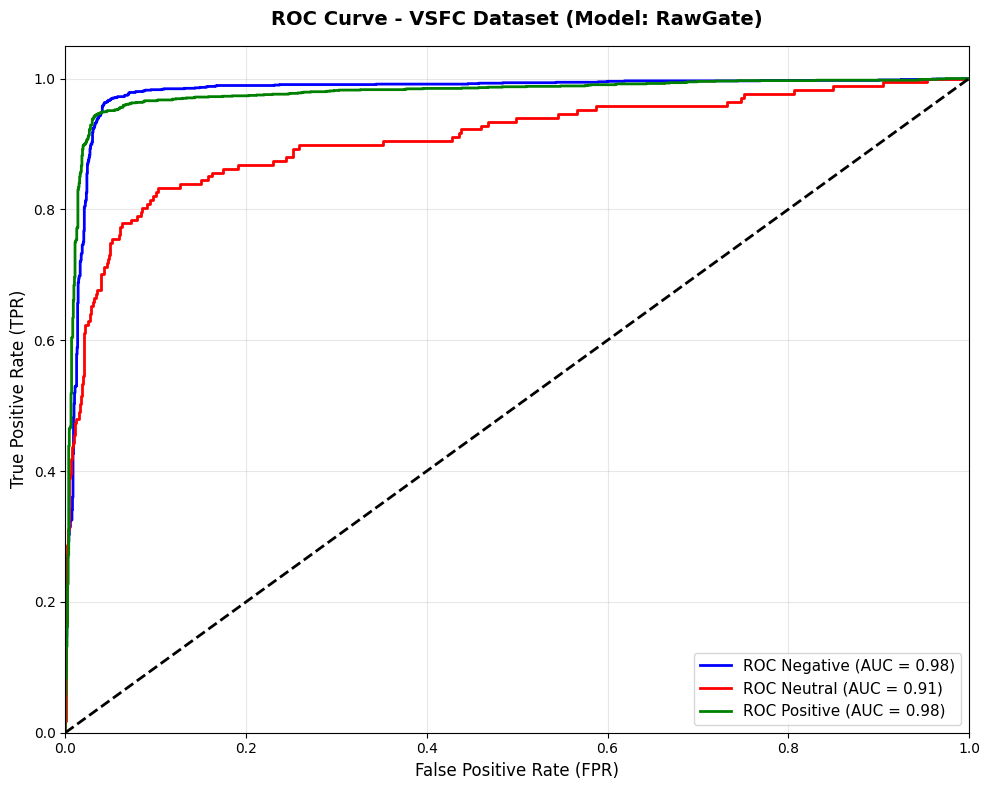

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch.nn.functional as F
import numpy as np
import torch

# Đảm bảo mô hình ở chế độ suy luận
m3.eval()

def plot_multiclass_roc(model, loader, device, classes):
    y_test = []
    y_score = []
    
    # 1. Thu thập xác suất dự đoán (probabilities) cho toàn bộ tập Test
    with torch.no_grad():
        for b in loader:
            ids = b['input_ids'].to(device)
            mask = b['attention_mask'].to(device)
            ont = b['ontology_features'].to(device)
            labels = b['labels'].to(device)

            outputs = model(ids, mask, ont)
            probs = F.softmax(outputs, dim=1)

            y_test.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_test = np.array(y_test)
    y_score = np.array(y_score)
    
    # 2. Binarize nhãn thực tế để tính Multiclass ROC (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=range(len(classes)))
    n_classes = len(classes)

    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    # Tính FPR, TPR và AUC cho từng class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # 3. Tiến hành vẽ biểu đồ
    plt.figure(figsize=(10, 8))
    
    # Tự động chọn màu dựa trên số lượng nhãn (VSFC có 3 nhãn)
    colors = ['blue', 'red', 'green', 'orange', 'purple'][:n_classes]
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC {0} (AUC = {1:0.2f})'.format(classes[i], roc_auc[i]))

    # Vẽ đường chéo ngẫu nhiên (Baseline 0.5)
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    # Tinh chỉnh giao diện
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title('ROC Curve - VSFC Dataset (Model: RawGate)', fontsize=14, fontweight='bold', pad=15)
    plt.legend(loc="lower right", fontsize=11)
    
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

print("🚀 ĐANG TÍNH TOÁN VÀ VẼ BIỂU ĐỒ ROC CHO VSFC...")

# Đã thay le.classes_ thành danh sách nhãn cứng của VSFC
VSFC_CLASSES = ['Negative', 'Neutral', 'Positive']
plot_multiclass_roc(m3, test_loader, device, VSFC_CLASSES)

🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH (VSFC)...

> Text Gốc: giảng viên nhiệt tình trong công tác giảng dạy .
> True Label: Positive


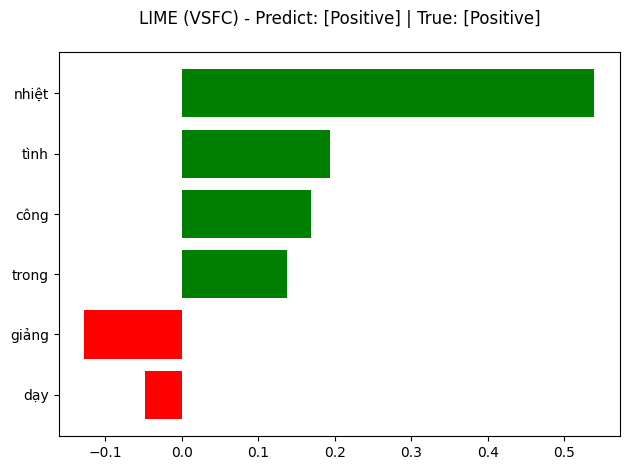

In [27]:
import gc
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer

m3.eval()

# Khai báo cứng danh sách nhãn cho VSFC
VSFC_CLASSES = ['Negative', 'Neutral', 'Positive']

# ==========================================
# 1. HÀM PREDICT "BỌC THÉP" CHỐNG SEGFAULT
# ==========================================
def m3_predict_proba_bulletproof(texts):
    all_probs = []
    batch_size = 16 
    
    # Ép toàn bộ input về kiểu chuỗi (String) thuần túy
    clean_texts = [str(t) for t in texts]
    
    for i in range(0, len(clean_texts), batch_size):
        batch_texts = clean_texts[i:i+batch_size]
        
        enc = tokenizer(batch_texts, max_length=128, padding='max_length', truncation=True, return_tensors='pt')
        
        ont_vectors = []
        for txt in batch_texts:
            try: 
                vec = ontengine.getvector(txt) 
            except: 
                vec = np.zeros(ONT_INPUT_DIM, dtype=np.float32)
            ont_vectors.append(vec)
            
        ids = enc['input_ids'].to(device)
        mask = enc['attention_mask'].to(device)
        ont = torch.tensor(np.array(ont_vectors), dtype=torch.float).to(device)
        
        with torch.no_grad():
            out = m3(ids, mask, ont)
            probs = F.softmax(out, dim=1).cpu().numpy()
            all_probs.extend(probs)
            
        del ids, mask, ont, out, enc
        torch.cuda.empty_cache()
        
    return np.array(all_probs)

# ==========================================
# 2. CHẠY LIME VÀ XUẤT ẢNH TĨNH CHO VSFC
# ==========================================
print("🚀 ĐANG CHẠY LIME VỚI CHẾ ĐỘ RENDER ẢNH (VSFC)...")

# SỬA LỖI Ở ĐÂY: Truyền VSFC_CLASSES thay vì le.classes_
lime_explainer = LimeTextExplainer(class_names=VSFC_CLASSES)

# Chọn index câu test (Bạn có thể đổi số này để xem các câu khác)
test_idx = 10
text_test = str(df_test.iloc[test_idx]['Sentence']) 
true_label_idx = int(df_test.iloc[test_idx]['Sentiment'])

# Lấy tên nhãn thực tế
true_label_name = VSFC_CLASSES[true_label_idx]

lime_exp = lime_explainer.explain_instance(
    text_test, 
    m3_predict_proba_bulletproof, 
    num_features=6, 
    top_labels=1,
    num_samples=100 
)

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label_name}")

# Xuất bằng Matplotlib
top_pred_idx = lime_exp.available_labels()[0]

# SỬA LỖI Ở ĐÂY: Dùng VSFC_CLASSES thay vì le.classes_
pred_label_name = VSFC_CLASSES[top_pred_idx]

fig = lime_exp.as_pyplot_figure(label=top_pred_idx)
plt.title(f"LIME (VSFC) - Predict: [{pred_label_name}] | True: [{true_label_name}]", pad=20)
plt.tight_layout()
plt.show()

🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER CHO VSFC...

> Text Gốc: giảng viên nhiệt tình trong công tác giảng dạy .
> True Label: Positive
> Model Predict: Positive (Xác suất: 1.00)
⏳ Đang tính toán Shapley Values...

📊 Đang xuất biểu đồ...


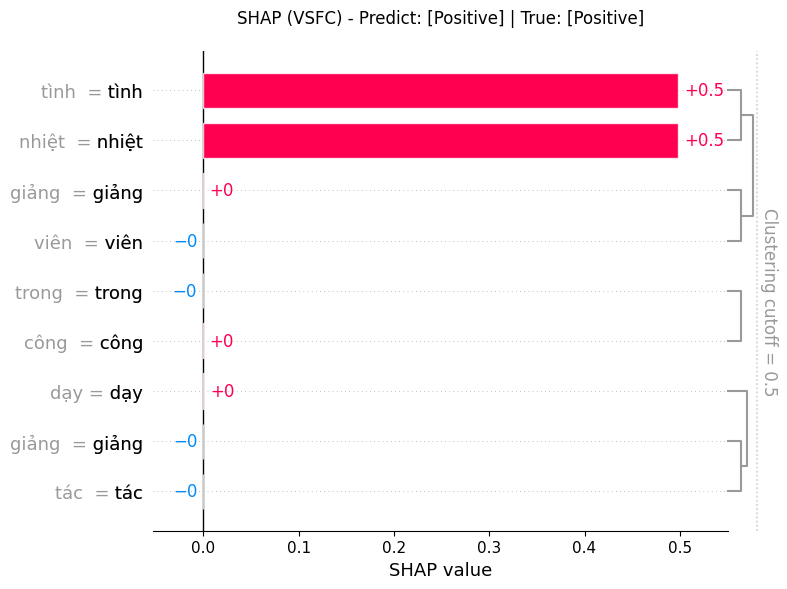

In [29]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Đảm bảo mô hình đang ở chế độ suy luận
m3.eval()

print("🚀 ĐANG KHỞI ĐỘNG SHAP EXPLAINER CHO VSFC...")

# Khai báo cứng danh sách nhãn cho VSFC
VSFC_CLASSES = ['Negative', 'Neutral', 'Positive']

# 1. MASKER AN TOÀN: Tránh lỗi Tokenizer
masker = shap.maskers.Text(r"\W+")

# 2. KHỞI TẠO EXPLAINER (Tận dụng lại hàm predict bọc thép từ Cell LIME ở trên)
# SỬA LỖI Ở ĐÂY: Dùng VSFC_CLASSES thay vì le.classes_
shap_explainer = shap.Explainer(m3_predict_proba_bulletproof, masker, output_names=VSFC_CLASSES)

# 3. CHUẨN BỊ DỮ LIỆU TEST
test_idx = 10
text_test = str(df_test.iloc[test_idx]['Sentence'])

# Lấy nhãn đúng dạng số và chuyển thành chữ
true_label_idx = int(df_test.iloc[test_idx]['Sentiment'])
true_label_name = VSFC_CLASSES[true_label_idx]

# Lấy nhãn dự đoán cao nhất
probs = m3_predict_proba_bulletproof([text_test])[0]
pred_idx = np.argmax(probs)
# SỬA LỖI Ở ĐÂY: Dùng VSFC_CLASSES thay vì le.classes_
pred_label = VSFC_CLASSES[pred_idx]

print(f"\n> Text Gốc: {text_test}")
print(f"> True Label: {true_label_name}")
print(f"> Model Predict: {pred_label} (Xác suất: {probs[pred_idx]:.2f})")
print("⏳ Đang tính toán Shapley Values...")

# 4. CHẠY SHAP (GIỚI HẠN TÀI NGUYÊN ĐỂ CHỐNG SẬP KAGGLE)
shap_values = shap_explainer([text_test], max_evals=150, batch_size=16)

# 5. VẼ BIỂU ĐỒ MATPLOTLIB BAR
print("\n📊 Đang xuất biểu đồ...")
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ Bar cho nhãn dự đoán cao nhất
shap.plots.bar(shap_values[0, :, pred_idx], show=False)

plt.title(f"SHAP (VSFC) - Predict: [{pred_label}] | True: [{true_label_name}]", pad=20)
plt.tight_layout()
plt.show()